# Estudio de resultados

Este notebook sirve para cargar los JSON con los resultados obtenidos y 
obtener gráficos con sus resultados para poder hacer una comparación directa 
de los mismos.

In [9]:
import sys
import os

path_to_add = os.path.abspath('../utils')
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

--------------  Resultados Piccolo+CVC+PolypDB  --------------
YOLO-base & 83.72 & 17.41 & 66.31 & 75.38
ViT-Small & 84.59 & 12.72 & 71.87 & 78.02
ViT-Large & 79.64 & 12.30 & 67.34 & 75.13
DeiT & 84.17 & 10.44 & 73.73 & 81.10
PVT & 87.24 & 9.95 & 77.29 & 82.26
YOLOv8 & 77.22 & 16.93 & 60.29 & 65.25
DenseNet & 82.11 & 17.11 & 65.00 & 67.18
Media transformers: 83.87 & 12.56 & 71.31 & 78.38
Media CNN: 79.66 & 17.02 & 62.64 & 66.22


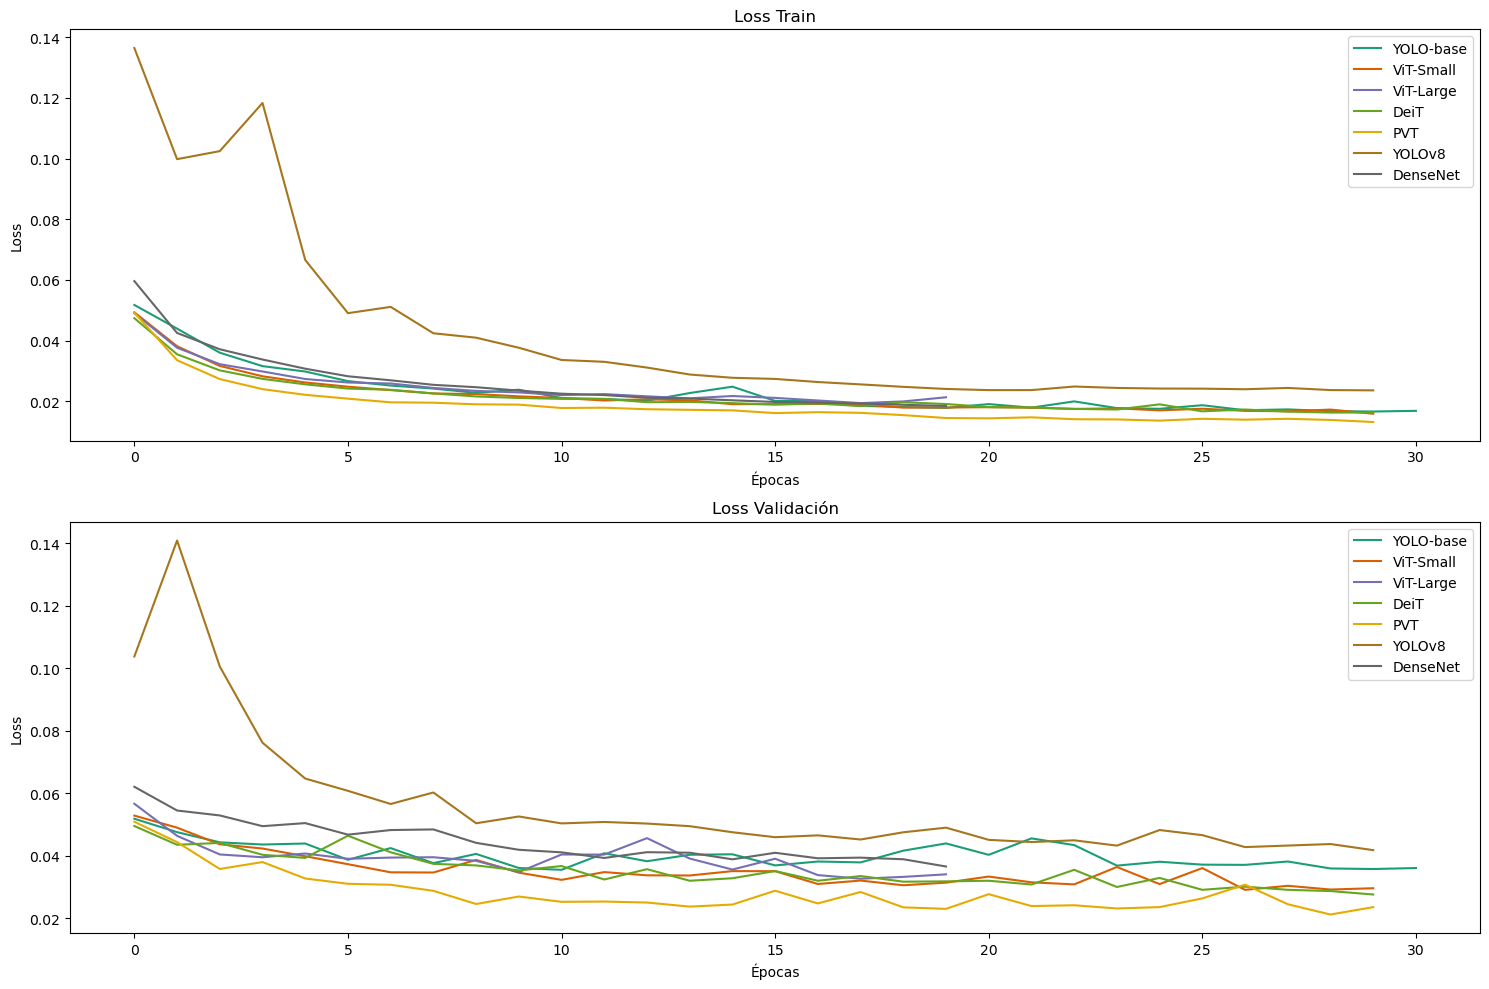

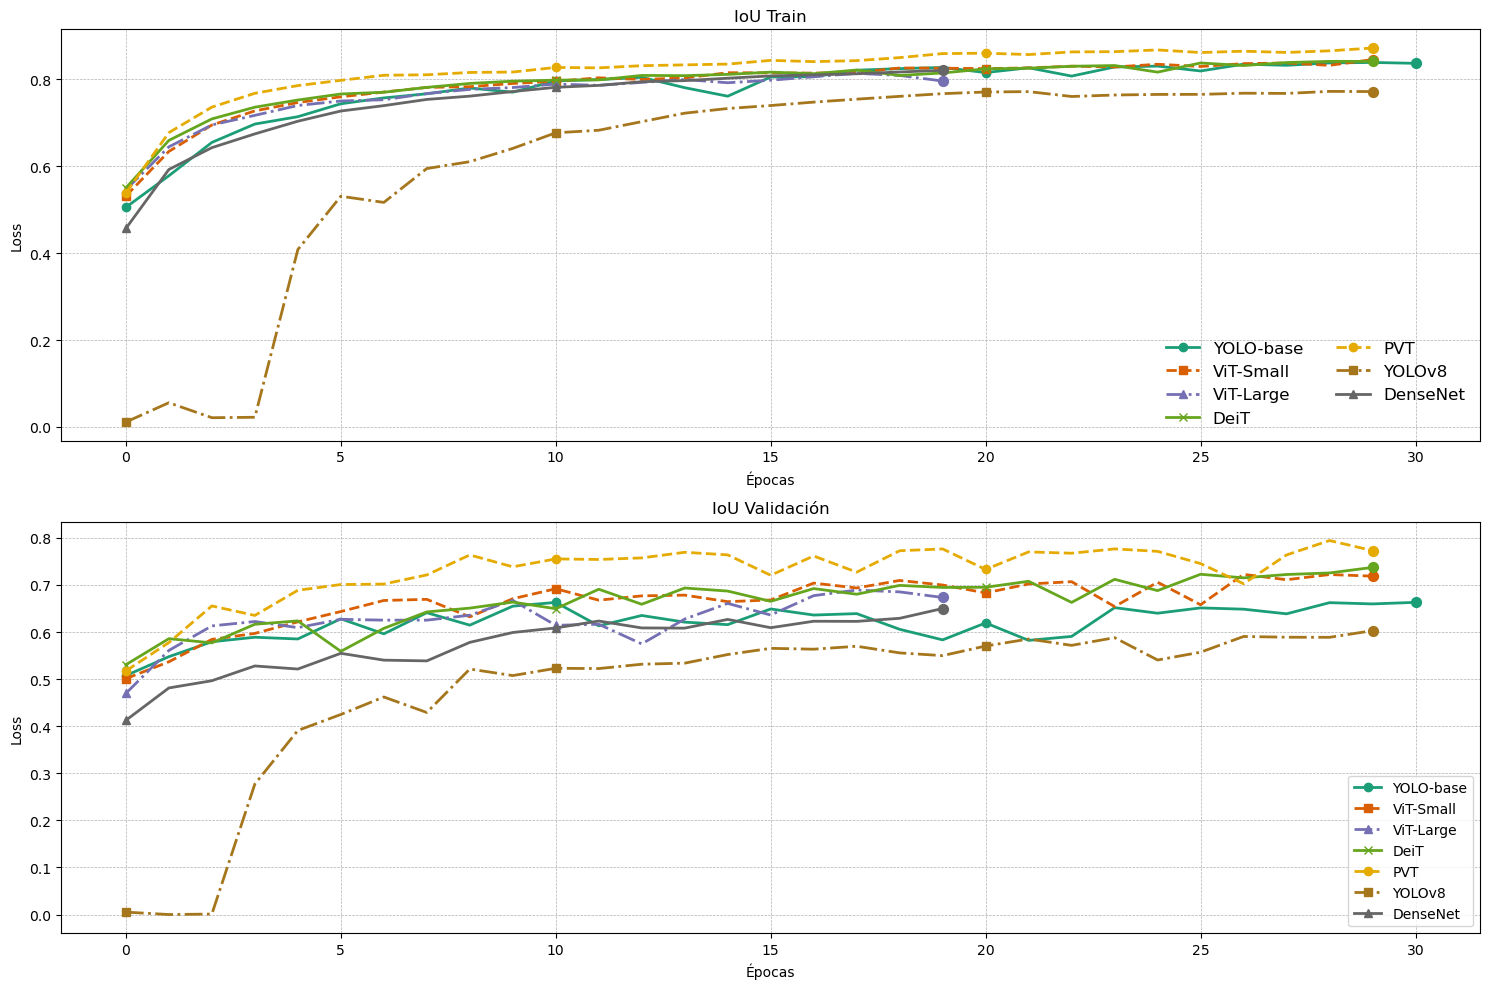

In [10]:
import graph_utils as gutils
import utils

dir_res = "../resultados"       # directorio de resultados
benchmark_name = "Piccolo+CVC+PolypDB"
paths = [
    "../resultados/YOLO-base/Piccolo+CVC+PolypDB_YOLO-base_31EP_480x240.json",
    "../resultados/ViT-Small/Piccolo+CVC+PolypDB_ViT-Small_30EP_384x384.json",
    "../resultados/ViT-Large/Piccolo+CVC+PolypDB_ViT-Large_20EP_384x384_CIoU.json",
    "../resultados/DeiT/Piccolo+CVC+PolypDB_DeiT_30EP_384x384.json",
    "../resultados/PVT/Piccolo+CVC+PolypDB_PVT_30EP_244x244.json",
    "../resultados/YOLOv8/Piccolo+CVC+PolypDB_YOLOv8_30EP_384x384.json",
    "../resultados/DenseNet/Piccolo+CVC+PolypDB_DenseNet_20EP_384x384.json"
]
    # "../resultados/YOLO-base/Piccolo_YOLO-base_50EP_480x240.json",
    # "../resultados/ViT-Small/Piccolo_ViT-Small_50EP_384x384.json",
    # "../resultados/ViT-Large/Piccolo_ViT-Large_30EP_384x384.json",
    # "../resultados/DeiT/Piccolo_DeiT_30EP_384x384.json",
    # "../resultados/PVT/Piccolo_PVT_30EP_244x244.json",
    # "../resultados/YOLOv8/Piccolo_YOLOv8_30EP_384x384.json",
    # "../resultados/DenseNet/Piccolo_DenseNet_30EP_384x384.json"
dict_names = []                 # lista de nombres de los resultados
dicts = []                      # lista con los resultados

# valores transformer
mean_ViT_train = 0
mean_ViT_val = 0
mean_ViT_test = 0
mean_ViT_overfit = 0
num_ViT = 5

# valores CNN
mean_CNN_train = 0
mean_CNN_val = 0
mean_CNN_test = 0
mean_CNN_overfit = 0
num_CNN = 2

print(f"--------------  Resultados {benchmark_name}  --------------")
for path in paths:
    new_dict = utils.load_json_dict(path)
    dicts.append(new_dict)
    base_dir = os.path.dirname(path)
    new_dict_name = os.path.basename(base_dir)
    dict_names.append(new_dict_name)    # guardamos su nombre
    res_train = new_dict['IoU_hist_train'][-1]
    res_val = new_dict['IoU_hist_val'][-1]

    print(f"{new_dict_name} & ", end="")
    print(f"{res_train*100:.2f} & ", end="")
    print(f"{(res_train-res_val)*100:.2f} & ", end="")
    print(f"{res_val*100:.2f} & ", end="")
    print(f"{new_dict['IoU_test']*100:.2f}")

    # obtnemos la media de las arquitecturas transformer
    if new_dict_name != "YOLOv8" and new_dict_name != "DenseNet":
        mean_ViT_train += new_dict['IoU_hist_train'][-1]
        mean_ViT_val += new_dict['IoU_hist_val'][-1]
        mean_ViT_test += new_dict['IoU_test']
        mean_ViT_overfit += res_train-res_val
    # Obtenemos la media de las arquitecturas CNN
    else:
        mean_CNN_train += new_dict['IoU_hist_train'][-1]
        mean_CNN_val += new_dict['IoU_hist_val'][-1]
        mean_CNN_test += new_dict['IoU_test']
        mean_CNN_overfit += res_train-res_val



#  Calculamos la media de las arquitecturas transformer
print(f"Media transformers: {(mean_ViT_train/num_ViT)*100:.2f}", end="")
print(f" & {(mean_ViT_overfit/num_ViT)*100:.2f}", end="")
print(f" & {(mean_ViT_val/num_ViT)*100:.2f}", end="")
print(f" & {(mean_ViT_test/num_ViT)*100:.2f}")

#  Calculamos la media de las arquitecturas CNN
print(f"Media CNN: {(mean_CNN_train/num_CNN)*100:.2f}", end="")
print(f" & {(mean_CNN_overfit/num_CNN)*100:.2f}", end="")
print(f" & {(mean_CNN_val/num_CNN)*100:.2f}", end="")
print(f" & {(mean_CNN_test/num_CNN)*100:.2f}")

gutils.show_Nresults(dicts, dict_names, save_img=True, img_name=f"{dir_res}/resultados_{benchmark_name}")